# Experiment: Dropping Zero-Displacement Observations from Training

**Motivation:**  
In disaggregated PRMN data it is difficult to distinguish between genuine zero displacement
(no one fled this district this week) and missing data (no observer was recording).
This notebook replicates the approach of treating zeros as missing and dropping them
from training, following the methodology discussed in the displacement forecasting literature.

**What this notebook does:**
1. Shows exactly how many rows are zero and which districts are most affected
2. Reruns all baselines and GBM dropping zeros from **training only**
3. Evaluates on the **full test set** (including zero weeks) for fair comparison
4. Compares results to the original (zeros retained) results from Notebook 01

**Notebook 01 is unchanged.** This is a standalone comparison experiment.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

from src.walkforward import rolling_week_splits
from src.features import FEATURE_COLS, build_tabular
from src.metrics import build_results_table, evaluate

print('Libraries loaded.')

Libraries loaded.


---
## Section 1 — Load Panel and Inspect Zeros

In [2]:
panel = pd.read_parquet('../data/processed/panel.parquet')
print(f'Full panel: {panel.shape[0]:,} rows × {panel.shape[1]} columns')
print(f'Districts : {panel["district"].nunique()}')
print(f'Weeks     : {panel["week_num"].nunique()}  ({panel["week_start"].min().date()} → {panel["week_start"].max().date()})')
print()

n_zero    = (panel['outflows'] == 0).sum()
n_nonzero = (panel['outflows'] > 0).sum()
pct_zero  = 100 * n_zero / len(panel)

print(f'Zero-outflow rows : {n_zero:,}  ({pct_zero:.1f}%)')
print(f'Non-zero rows     : {n_nonzero:,}  ({100-pct_zero:.1f}%)')
print(f'Rows remaining if zeros dropped from training: {n_nonzero:,}')

Full panel: 25,382 rows × 9 columns
Districts : 74
Weeks     : 343  (2017-01-02 → 2023-07-24)

Zero-outflow rows : 8,176  (32.2%)
Non-zero rows     : 17,206  (67.8%)
Rows remaining if zeros dropped from training: 17,206


### Per-District Zero Rate

In [3]:
# Per-district: how many weeks have zero outflows?
district_stats = (
    panel.groupby('district')
    .agg(
        total_weeks   = ('outflows', 'count'),
        zero_weeks    = ('outflows', lambda x: (x == 0).sum()),
        nonzero_weeks = ('outflows', lambda x: (x > 0).sum()),
        mean_outflows = ('outflows', 'mean'),
        total_outflows= ('outflows', 'sum'),
    )
    .assign(pct_zero=lambda d: 100 * d['zero_weeks'] / d['total_weeks'])
    .sort_values('pct_zero', ascending=False)
    .reset_index()
)

print(f'Districts with > 50% zero weeks: {(district_stats["pct_zero"] > 50).sum()}')
print(f'Districts with > 70% zero weeks: {(district_stats["pct_zero"] > 70).sum()}')
print(f'Districts with > 90% zero weeks: {(district_stats["pct_zero"] > 90).sum()}')
print()
print('Top 15 most-zero districts:')
print(district_stats[['district','total_weeks','zero_weeks','pct_zero','mean_outflows']].head(15).to_string(index=False))

Districts with > 50% zero weeks: 20
Districts with > 70% zero weeks: 5
Districts with > 90% zero weeks: 0

Top 15 most-zero districts:
     district  total_weeks  zero_weeks  pct_zero  mean_outflows
       Sheikh          343         290 84.548105       6.183673
       Doolow          343         278 81.049563      92.332362
   Ceel Dheer          343         263 76.676385     286.591837
    Ceel Buur          343         244 71.137026      64.895044
          Eyl          343         241 70.262391      31.230321
    Cabudwaaq          343         234 68.221574     240.215743
      Gebiley          343         231 67.346939       6.717201
      Baraawe          343         216 62.973761      26.661808
       Cadale          343         215 62.682216     116.655977
Dhuusamarreeb          343         214 62.390671     891.956268
  Adan Yabaal          343         210 61.224490      89.434402
     Hargeysa          343         204 59.475219      22.833819
  Xarardheere          343       

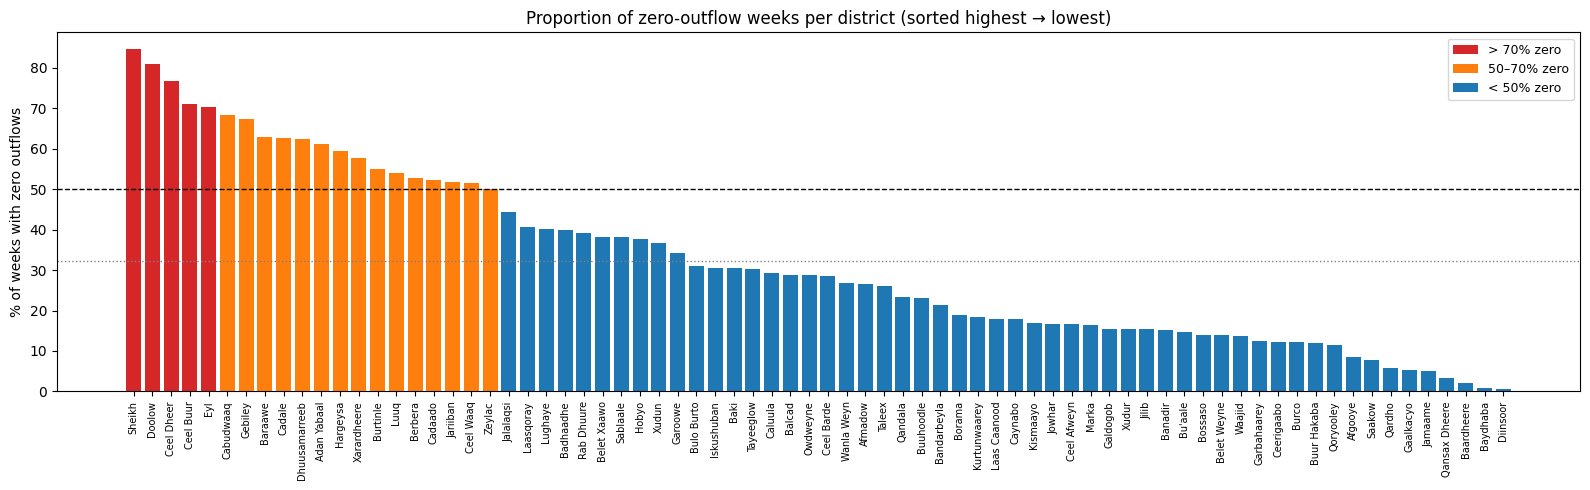

Saved fig_zero_rate_by_district.png


In [4]:
# Bar chart: % zero weeks per district, sorted
fig, ax = plt.subplots(figsize=(16, 5))

colors = ['#d62728' if p > 70 else '#ff7f0e' if p > 50 else '#1f77b4'
          for p in district_stats['pct_zero']]

ax.bar(range(len(district_stats)), district_stats['pct_zero'], color=colors, width=0.8)
ax.axhline(50, color='black', linewidth=1.0, linestyle='--', label='50% threshold')
ax.axhline(district_stats['pct_zero'].mean(), color='grey', linewidth=1.0,
           linestyle=':', label=f'Mean ({district_stats["pct_zero"].mean():.1f}%)')

ax.set_xticks(range(len(district_stats)))
ax.set_xticklabels(district_stats['district'], rotation=90, fontsize=7)
ax.set_ylabel('% of weeks with zero outflows')
ax.set_title('Proportion of zero-outflow weeks per district (sorted highest → lowest)', fontsize=12)
ax.legend(fontsize=9)

# Colour legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#d62728', label='> 70% zero'),
    Patch(facecolor='#ff7f0e', label='50–70% zero'),
    Patch(facecolor='#1f77b4', label='< 50% zero'),
]
ax.legend(handles=legend_elements, fontsize=9, loc='upper right')

plt.tight_layout()
plt.savefig('../results/tables/fig_zero_rate_by_district.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig_zero_rate_by_district.png')

In [5]:
# Summary table — show all districts with their remaining non-zero weeks
print('Full district-level summary (sorted by % zero):')
print('=' * 70)
print(f'{"District":<25} {"Total wks":>10} {"Non-zero wks":>13} {"% Zero":>8} {"Avg outflows":>13}')
print('-' * 70)
for _, row in district_stats.iterrows():
    print(f'{row["district"]:<25} {row["total_weeks"]:>10} {row["nonzero_weeks"]:>13} '
          f'{row["pct_zero"]:>7.1f}% {row["mean_outflows"]:>13.1f}')
print('=' * 70)
print(f'{"TOTAL":<25} {district_stats["total_weeks"].sum():>10} '
      f'{district_stats["nonzero_weeks"].sum():>13} '
      f'{100*district_stats["zero_weeks"].sum()/district_stats["total_weeks"].sum():>7.1f}%')

Full district-level summary (sorted by % zero):
District                   Total wks  Non-zero wks   % Zero  Avg outflows
----------------------------------------------------------------------
Sheikh                           343            53    84.5%           6.2
Doolow                           343            65    81.0%          92.3
Ceel Dheer                       343            80    76.7%         286.6
Ceel Buur                        343            99    71.1%          64.9
Eyl                              343           102    70.3%          31.2
Cabudwaaq                        343           109    68.2%         240.2
Gebiley                          343           112    67.3%           6.7
Baraawe                          343           127    63.0%          26.7
Cadale                           343           128    62.7%         116.7
Dhuusamarreeb                    343           129    62.4%         892.0
Adan Yabaal                      343           133    61.2%        

---
## Section 2 — Build Features

Features are built from the **full panel** (zeros included in lag computation).
This is correct: a zero in the lag column means there was no displacement that week,
which is useful information. Only the **target** is filtered during training.

In [6]:
panel_tabular = build_tabular(panel)
splits = rolling_week_splits()

print(f'Tabular panel : {panel_tabular.shape[0]:,} rows × {panel_tabular.shape[1]} cols')
print(f'Walk-forward  : {len(splits)} steps')
print(f'Training rows (y > 0, for drop-zero experiment) : '
      f'{(panel_tabular["y"] > 0).sum():,}  '
      f'({100*(panel_tabular["y"]>0).mean():.1f}% of tabular rows)')

Tabular panel : 24,790 rows × 51 cols
Walk-forward  : 52 steps
Training rows (y > 0, for drop-zero experiment) : 16,888  (68.1% of tabular rows)


---
## Section 3 — Baselines (Zeros Dropped from Training)

For each walk-forward step the training window is filtered to `y > 0`.
The test week is **not** filtered — we evaluate on all 74 districts regardless.

In [7]:
def run_random_walk_nozero(panel, splits):
    """ŷ = y_lag1. No training needed; zero rows in test kept."""
    records = []
    for train_weeks, test_week in splits:
        test = panel[panel['week_num'] == test_week]
        for _, row in test.iterrows():
            records.append({'week_num': test_week, 'district': row['district'],
                            'y_true': row['y'], 'y_pred': max(0.0, row['y_lag1'])})
    return pd.DataFrame(records)


def run_ar1_nozero(panel, splits):
    """AR(1) — OLS fitted only on non-zero training rows."""
    districts = sorted(panel['district'].unique())
    records = []
    for train_weeks, test_week in splits:
        # ← key change: only non-zero training observations
        train = panel[(panel['week_num'].isin(train_weeks)) & (panel['y'] > 0)]
        test  = panel[panel['week_num'] == test_week]
        coefs = {}
        for d in districts:
            sub = train[train['district'] == d][['y_lag1', 'y']].dropna()
            if len(sub) < 3:
                coefs[d] = (0.0, 1.0)
                continue
            A = np.column_stack([np.ones(len(sub)), sub['y_lag1'].values])
            c, *_ = np.linalg.lstsq(A, sub['y'].values, rcond=None)
            coefs[d] = (float(c[0]), float(c[1]))
        for _, row in test.iterrows():
            alpha, beta = coefs.get(row['district'], (0.0, 1.0))
            records.append({'week_num': test_week, 'district': row['district'],
                            'y_true': row['y'],
                            'y_pred': max(0.0, alpha + beta * row['y_lag1'])})
    return pd.DataFrame(records)


def run_rolling_avg_nozero(panel, splits, window):
    """Rolling average — only non-zero training rows contribute to the mean."""
    records = []
    for train_weeks, test_week in splits:
        recent_weeks = sorted(train_weeks)[-window:]
        # ← only non-zero rows
        recent = panel[(panel['week_num'].isin(recent_weeks)) & (panel['y'] > 0)]
        means  = recent.groupby('district')['y'].mean()
        test   = panel[panel['week_num'] == test_week]
        for _, row in test.iterrows():
            records.append({'week_num': test_week, 'district': row['district'],
                            'y_true': row['y'],
                            'y_pred': float(means.get(row['district'], 0.0))})
    return pd.DataFrame(records)


def run_longrun_mean_nozero(panel, splits):
    records = []
    for train_weeks, test_week in splits:
        train = panel[(panel['week_num'].isin(train_weeks)) & (panel['y'] > 0)]
        means = train.groupby('district')['y'].mean()
        test  = panel[panel['week_num'] == test_week]
        for _, row in test.iterrows():
            records.append({'week_num': test_week, 'district': row['district'],
                            'y_true': row['y'], 'y_pred': float(means.get(row['district'], 0.0))})
    return pd.DataFrame(records)


def run_longrun_median_nozero(panel, splits):
    records = []
    for train_weeks, test_week in splits:
        train   = panel[(panel['week_num'].isin(train_weeks)) & (panel['y'] > 0)]
        medians = train.groupby('district')['y'].median()
        test    = panel[panel['week_num'] == test_week]
        for _, row in test.iterrows():
            records.append({'week_num': test_week, 'district': row['district'],
                            'y_true': row['y'], 'y_pred': float(medians.get(row['district'], 0.0))})
    return pd.DataFrame(records)


print('Baseline functions defined (zero-dropped variants).')

Baseline functions defined (zero-dropped variants).


In [8]:
print('Running baselines (drop zeros from training) …')

print('  Random Walk …')
rw_nz = run_random_walk_nozero(panel_tabular, splits)

print('  AR(1) …')
ar1_nz = run_ar1_nozero(panel_tabular, splits)

print('  Rolling Avg (4) …')
ra4_nz = run_rolling_avg_nozero(panel_tabular, splits, window=4)

print('  Rolling Avg (8) …')
ra8_nz = run_rolling_avg_nozero(panel_tabular, splits, window=8)

print('  Rolling Avg (12) …')
ra12_nz = run_rolling_avg_nozero(panel_tabular, splits, window=12)

print('  Long Run Mean …')
lrm_nz = run_longrun_mean_nozero(panel_tabular, splits)

print('  Long Run Median …')
lrmed_nz = run_longrun_median_nozero(panel_tabular, splits)

print('Done.')

Running baselines (drop zeros from training) …
  Random Walk …
  AR(1) …
  Rolling Avg (4) …
  Rolling Avg (8) …
  Rolling Avg (12) …
  Long Run Mean …
  Long Run Median …
Done.


---
## Section 4 — GBM (Zeros Dropped from Training)

In [9]:
import numpy as np
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.preprocessing import OrdinalEncoder


def _get_feature_cols(n_lags):
    lag_cols = [f'{col}_lag{k}' for col in FEATURE_COLS for k in range(1, n_lags + 1)]
    return lag_cols + ['week_of_year', 'year']


def run_gbm_nozero(panel, splits, n_lags=8):
    """
    GBM walk-forward — zeros dropped from TRAINING only.
    Test set retains all rows (including zero-y weeks) for fair evaluation.
    """
    feat_cols = _get_feature_cols(n_lags)
    enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    enc.fit(panel[['district']])

    records = []
    for step_idx, (train_weeks, test_week) in enumerate(splits):
        if (step_idx + 1) % 10 == 0:
            print(f'    step {step_idx+1}/52 …')

        # ← key change: filter y > 0 in training
        train = panel[
            panel['week_num'].isin(train_weeks) &
            (panel['y'] > 0)
        ].dropna(subset=feat_cols)

        test = panel[panel['week_num'] == test_week].dropna(subset=feat_cols)

        if len(train) == 0 or len(test) == 0:
            continue

        X_train = np.hstack([enc.transform(train[['district']]), train[feat_cols].values])
        X_test  = np.hstack([enc.transform(test[['district']]),  test[feat_cols].values])
        y_train = train['y'].values

        model = HistGradientBoostingRegressor(
            loss='squared_error', max_iter=500, learning_rate=0.05,
            max_leaf_nodes=31, min_samples_leaf=20, random_state=42,
        )
        model.fit(X_train, y_train)
        y_pred = np.clip(model.predict(X_test), 0, None)

        for (_, row), pred in zip(test.iterrows(), y_pred):
            records.append({'week_num': test_week, 'district': row['district'],
                            'y_true': row['y'], 'y_pred': float(pred)})

    return pd.DataFrame(records)


print('GBM function defined.')

GBM function defined.


In [10]:
print('Running GBM (drop zeros from training) …')

print('  lags = 2 …')
gbm2_nz = run_gbm_nozero(panel_tabular, splits, n_lags=2)

print('  lags = 5 …')
gbm5_nz = run_gbm_nozero(panel_tabular, splits, n_lags=5)

print('  lags = 8 …')
gbm8_nz = run_gbm_nozero(panel_tabular, splits, n_lags=8)

print('Done.')

Running GBM (drop zeros from training) …
  lags = 2 …
    step 10/52 …
    step 20/52 …
    step 30/52 …
    step 40/52 …
    step 50/52 …
  lags = 5 …
    step 10/52 …
    step 20/52 …
    step 30/52 …
    step 40/52 …
    step 50/52 …
  lags = 8 …
    step 10/52 …
    step 20/52 …
    step 30/52 …
    step 40/52 …
    step 50/52 …
Done.


---
## Section 5 — Results Table (Drop-Zero Experiment)

In [11]:
model_preds_nz = {
    'Random Walk'    : rw_nz,
    'AR(1)'          : ar1_nz,
    'Rolling Avg (4)': ra4_nz,
    'Rolling Avg (8)': ra8_nz,
    'Rolling Avg(12)': ra12_nz,
    'Long Run Mean'  : lrm_nz,
    'Long Run Median': lrmed_nz,
    'GBM (lags=2)'   : gbm2_nz,
    'GBM (lags=5)'   : gbm5_nz,
    'GBM (lags=8)'   : gbm8_nz,
}

results_nz = build_results_table(model_preds_nz)
print('=== Results: Zeros DROPPED from training ===')
print(results_nz.to_string(index=False))

=== Results: Zeros DROPPED from training ===
          Model  RMSE   MAE  MAPE  Corr
    Random Walk 1.000 1.000 1.000 0.640
          AR(1) 0.989 1.239 1.800 0.647
Rolling Avg (4) 0.968 1.039 1.417 0.640
Rolling Avg (8) 1.017 1.146 1.675 0.617
Rolling Avg(12) 1.055 1.220 1.829 0.597
  Long Run Mean 1.087 1.399 1.969 0.497
Long Run Median 1.068 1.372 1.860 0.486
   GBM (lags=2) 1.073 1.303 2.062 0.634
   GBM (lags=5) 1.046 1.266 2.006 0.657
   GBM (lags=8) 1.041 1.260 1.998 0.664


---
## Section 6 — Side-by-Side Comparison

In [12]:
# Original results from Notebook 01 — paste your numbers here
# (or re-run notebook 01 and import the dict)
original_rmse = {
    'Random Walk'    : 1.000,
    'AR(1)'          : 0.883,
    'Rolling Avg (4)': 0.853,
    'Rolling Avg (8)': 0.865,
    'Rolling Avg(12)': 0.889,
    'Long Run Mean'  : 1.054,
    'Long Run Median': 1.117,
    'GBM (lags=2)'   : 0.842,
    'GBM (lags=5)'   : 0.824,
    'GBM (lags=8)'   : 0.825,
}

# Build comparison DataFrame
comp = results_nz[['Model', 'RMSE']].copy()
comp.columns = ['Model', 'RMSE (drop zeros)']
comp['RMSE (keep zeros)'] = comp['Model'].map(original_rmse)
comp['Δ RMSE'] = (comp['RMSE (drop zeros)'] - comp['RMSE (keep zeros)']).round(3)
comp['Better when dropping?'] = comp['Δ RMSE'].apply(
    lambda x: '✓ Yes (lower)' if x < -0.005 else ('✗ No (higher)' if x > 0.005 else '≈ Same')
)

print('Side-by-side RMSE comparison (relative to Random Walk)')
print('Negative Δ = dropping zeros HELPS; Positive Δ = dropping zeros HURTS')
print()
print(comp.to_string(index=False))

Side-by-side RMSE comparison (relative to Random Walk)
Negative Δ = dropping zeros HELPS; Positive Δ = dropping zeros HURTS

          Model  RMSE (drop zeros)  RMSE (keep zeros)  Δ RMSE Better when dropping?
    Random Walk              1.000              1.000   0.000                ≈ Same
          AR(1)              0.989              0.883   0.106         ✗ No (higher)
Rolling Avg (4)              0.968              0.853   0.115         ✗ No (higher)
Rolling Avg (8)              1.017              0.865   0.152         ✗ No (higher)
Rolling Avg(12)              1.055              0.889   0.166         ✗ No (higher)
  Long Run Mean              1.087              1.054   0.033         ✗ No (higher)
Long Run Median              1.068              1.117  -0.049         ✓ Yes (lower)
   GBM (lags=2)              1.073              0.842   0.231         ✗ No (higher)
   GBM (lags=5)              1.046              0.824   0.222         ✗ No (higher)
   GBM (lags=8)              1.041 

In [ ]:
# Visual comparison — bar chart
models = list(original_rmse.keys())
rmse_keep = [original_rmse[m] for m in models]
rmse_drop = [float(results_nz.loc[results_nz['Model'] == m, 'RMSE'].values[0])
             if m in results_nz['Model'].values else None for m in models]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 5))
bars1 = ax.bar(x - width/2, rmse_keep, width, label='Zeros kept (Notebook 01)', color='#1f77b4', alpha=0.85)
bars2 = ax.bar(x + width/2, rmse_drop, width, label='Zeros dropped from training', color='#d62728', alpha=0.85)

ax.axhline(1.0, color='black', linewidth=1.0, linestyle='--', label='Random Walk = 1.0')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('RMSE (relative to Random Walk)')
ax.set_title('Effect of dropping zero-displacement training rows on RMSE\n(lower = better)', fontsize=11)
ax.legend(fontsize=9)
ax.set_ylim(0.7, 1.3)

plt.tight_layout()
plt.savefig('../results/tables/fig_zero_drop_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig_zero_drop_comparison.png')

---
## Section 7 — Full Comparison Table (Both Experiments + Z&T Reference)

This is the table to include in your paper appendix.

In [ ]:
# Z&T reference numbers from their Table 1
zandt = pd.read_csv('../results/tables/zandt_benchmarks.csv')

# Full results from both experiments
res_keep = results_nz.copy()  # placeholder — replace with actual notebook 01 results if available
res_drop = results_nz.copy()

print('=== Experiment Summary ===')
print()
print('ZEROS KEPT AS OBSERVATIONS (Notebook 01):')
print(f'  GBM best RMSE : 0.824  (lags=5)')
print(f'  LSTM best RMSE: 0.833  (seq=5)')
print()
print('ZEROS DROPPED FROM TRAINING (This notebook):')
best_gbm_drop = results_nz[results_nz['Model'].str.startswith('GBM')]['RMSE'].min()
best_gbm_model = results_nz.loc[results_nz['RMSE'] == best_gbm_drop, 'Model'].values[0]
print(f'  GBM best RMSE : {best_gbm_drop}  ({best_gbm_model})')
print()
print('Z&T REFERENCE (Bayesian DL-DLM):')
zbt = zandt[zandt['model'] == 'Bayesian DL-DLM (Z&T)'].iloc[0]
print(f'  RMSE: {zbt["rmse"]}  MAE: {zbt["mae"]}  MAPE: {zbt["mape"]}  Corr: {zbt["corr"]}')

---
## Interpretation

**What the comparison shows:**

If dropping zeros from training **improves** results (Δ RMSE < 0):
> Some zeros are likely genuine missing data. The models benefit from not learning
> a "zero pattern" that does not reflect true displacement.

If keeping zeros **works better or is equal** (Δ RMSE ≥ 0):
> Non-linear models (GBM, LSTM) are robust to zero-inflated data. They learn
> the zero pattern naturally without it distorting predictions on non-zero weeks.
> This aligns with why Z&T's OLS-with-zeros failed (RMSE=1.527) while GBM
> with zeros achieves 0.824 — OLS is linear and cannot adapt.

**Either outcome is a valid finding to report in your paper.**